# PaleoWave — 07 LOO Validation (Proper Spatial Background)
**Project PaleoWave | Notebook 07**

Honest model evaluation using Leave-One-Out cross-validation with a
geographically realistic background — 0.1° regular grid with a 25km
exclusion buffer around all known presence points.

## Why standard AUC is inflated
Training background points are random pixels from the same extent as
presence points. With n=18 unique locations the RF trivially memorises
the training set → AUC 1.000 in notebook 06. Meaningless.

## Why LOO recall is the honest metric
At n<50 spatial autocorrelation inflates block-CV AUC to ~1.0.
LOO asks: *if we withheld this known site from training, would the
model still rank it highly?*  A site scoring in the top 10% of
background is a correct prediction.

## Background design
- 0.1° regular grid across the Nevada study extent
- 25km exclusion buffer around all presence points
  (tighter than IceWave 50km — Nevada sites are tightly clustered)
- Terrain features fetched from USGS 3DEP for each grid point
- Target: ~200–300 background points

## What this notebook does
1. Build proper spatial background (or load cache)
2. Run LOO — for each presence point: train on n-1, score held-out
3. Compute recall @ top 10% threshold
4. Compare v1 model recall vs v2 (TPI post-hoc)
5. Plot LOO predictions
6. Save final model and validation stats

In [1]:
# ── Cell 1: Imports and config ─────────────────────────────────────────────
import requests, time, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.ndimage import uniform_filter
from scipy.spatial.distance import cdist
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
warnings.filterwarnings('ignore')
from pathlib import Path

DATA_DIR  = Path('../data')
MODEL_DIR = DATA_DIR / 'model'
PBDB_DIR  = DATA_DIR / 'pbdb'
OUT_DIR   = Path('../outputs')

TNM_URL    = 'https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer'
TPI_RADIUS = 100
MAX_PX     = 500
FETCH_RES  = 0.00016
TILE_BUF   = 0.05

FEATURE_COLS = ['elevation_m', 'slope_deg', 'aspect_deg', 'tri']
RF_PARAMS    = dict(n_estimators=500, max_depth=6,
                    class_weight='balanced', random_state=42, n_jobs=-1)
EXCL_KM      = 25.0   # exclusion buffer around presence points
GRID_DEG     = 0.10   # background grid spacing

print('Imports OK')
print(f'Exclusion buffer: {EXCL_KM}km  |  Grid spacing: {GRID_DEG}°')

Imports OK
Exclusion buffer: 25.0km  |  Grid spacing: 0.1°


In [2]:
# ── Cell 2: Utility functions ──────────────────────────────────────────────

def fetch_dtm(lat, lon, buf=TILE_BUF, label='pt'):
    xmin, xmax = lon - buf, lon + buf
    ymin, ymax = lat - buf, lat + buf
    n = min(MAX_PX, int(buf * 2 / FETCH_RES))
    params = dict(
        bbox=f'{xmin},{ymin},{xmax},{ymax}', bboxSR='4326',
        size=f'{n},{n}', imageSR='4326', format='tiff',
        pixelType='F32', noDataInterpretation='esriNoDataMatchAny',
        interpolation='RSP_BilinearInterpolation', f='image'
    )
    for attempt in range(3):
        try:
            r = requests.get(f'{TNM_URL}/exportImage', params=params, timeout=60)
            r.raise_for_status()
            if len(r.content) < 1000: return None, None
            with rasterio.MemoryFile(r.content) as mf:
                with mf.open() as src:
                    dem = src.read(1).astype(np.float32)
                    tf  = src.transform
                    nd  = src.nodata
            if nd is not None: dem[dem == nd] = np.nan
            dem[dem < -500] = np.nan
            return dem, tf
        except requests.exceptions.ReadTimeout:
            if attempt < 2:
                print(f'  {label}: timeout, retry {attempt+2}/3...')
                time.sleep(2)
        except Exception:
            return None, None
    return None, None

def compute_tpi(dem):
    d = dem.copy()
    nm = np.isnan(d)
    if nm.any():
        tmp = uniform_filter(np.where(nm, 0., d), size=5)
        cnt = uniform_filter((~nm).astype(float), size=5)
        d[nm] = np.where(cnt[nm] > 0, tmp[nm]/cnt[nm], 0)
    return d - uniform_filter(d, size=TPI_RADIUS * 2 + 1)

def px_val(arr, tf, lat, lon):
    r = int((lat - tf.f) / tf.e)
    c = int((lon - tf.c) / tf.a)
    if 0 <= r < arr.shape[0] and 0 <= c < arr.shape[1]:
        return float(arr[r, c])
    return np.nan

def terrain_features(lat, lon, label='pt'):
    """Fetch DTM and return dict of terrain features at lat/lon."""
    dem, tf = fetch_dtm(lat, lon, label=label)
    if dem is None:
        return None
    res_m    = FETCH_RES * 111000
    dz_dx    = np.gradient(dem, axis=1) / res_m
    dz_dy    = np.gradient(dem, axis=0) / res_m
    slope_a  = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
    aspect_a = np.degrees(np.arctan2(-dz_dy, dz_dx)) % 360
    tri_a    = np.abs(dem - uniform_filter(dem, size=3))
    vals = {f: px_val(a, tf, lat, lon)
            for f, a in zip(FEATURE_COLS,
                            [dem, slope_a, aspect_a, tri_a])}
    if any(np.isnan(v) for v in vals.values()):
        return None
    return vals

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

print('Functions OK')

Functions OK


In [3]:
# ── Cell 3: Load presence points ───────────────────────────────────────────

pres_feat_path = DATA_DIR / 'features_pbdb_terrain.csv'
pres_tpi_path  = PBDB_DIR / 'pbdb_presence_tpi.csv'

df_terrain = pd.read_csv(pres_feat_path)
df_pres = (df_terrain
    .drop_duplicates(subset=['latitude','longitude'])
    .dropna(subset=FEATURE_COLS)
    .copy()
    .reset_index(drop=True))
df_pres['label'] = 1

pres_coords = df_pres[['latitude','longitude']].values

print(f'Presence points: {len(df_pres)} unique locations')
print(f'Lat: {df_pres.latitude.min():.3f} – {df_pres.latitude.max():.3f}')
print(f'Lon: {df_pres.longitude.min():.3f} – {df_pres.longitude.max():.3f}')
print()
print(df_pres[FEATURE_COLS].describe().round(2).to_string())

Presence points: 16 unique locations
Lat: 38.402 – 40.548
Lon: -118.300 – -117.533

       elevation_m  slope_deg  aspect_deg    tri
count        16.00      16.00       16.00  16.00
mean       1699.63      16.70      150.48   2.43
std         248.87      10.26      122.56   1.64
min        1386.40       2.91        4.60   0.41
25%        1561.28       9.42       62.66   1.28
50%        1695.20      13.22      124.56   1.72
75%        1740.39      26.67      260.21   3.91
max        2355.01      34.16      358.55   5.68


In [4]:
# ── Cell 4: Build proper spatial background ────────────────────────────────
# 0.1° regular grid, 25km exclusion buffer, terrain features fetched

bg_proper_path = PBDB_DIR / 'paleowave_background_proper.csv'

if bg_proper_path.exists():
    df_bg = pd.read_csv(bg_proper_path)
    print(f'Proper background loaded from cache: {len(df_bg)} points')
else:
    # Build grid
    lat_lo = df_pres.latitude.min()  - 1.0
    lat_hi = df_pres.latitude.max()  + 1.0
    lon_lo = df_pres.longitude.min() - 1.0
    lon_hi = df_pres.longitude.max() + 1.0

    grid_lats = np.arange(lat_lo, lat_hi, GRID_DEG)
    grid_lons = np.arange(lon_lo, lon_hi, GRID_DEG)
    lats_g, lons_g = np.meshgrid(grid_lats, grid_lons)
    grid_pts = np.column_stack([lats_g.ravel(), lons_g.ravel()])
    print(f'Grid points before exclusion: {len(grid_pts)}')

    # Apply exclusion buffer
    keep = []
    for glat, glon in grid_pts:
        dists = [haversine_km(glat, glon, plat, plon)
                 for plat, plon in pres_coords]
        if min(dists) >= EXCL_KM:
            keep.append((glat, glon))
    print(f'Grid points after {EXCL_KM}km exclusion: {len(keep)}')

    # Fetch terrain features
    rows = []
    for i, (glat, glon) in enumerate(keep):
        label = f'bg{i+1}'
        feats = terrain_features(glat, glon, label=label)
        if feats is None:
            continue
        feats.update(latitude=glat, longitude=glon, label=0)
        rows.append(feats)
        if (i+1) % 25 == 0:
            print(f'  {len(rows)} valid / {i+1} attempted...')

    df_bg = pd.DataFrame(rows)
    df_bg.to_csv(bg_proper_path, index=False)
    print(f'Saved: {bg_proper_path}')

df_bg['label'] = 0
print(f'\nBackground: {len(df_bg)} points')
print(f'Presence:   {len(df_pres)} points')
print(f'Ratio:      {len(df_bg)/len(df_pres):.1f}:1')

Grid points before exclusion: 1176
Grid points after 25.0km exclusion: 1029
  24 valid / 25 attempted...
  49 valid / 50 attempted...
  74 valid / 75 attempted...
  99 valid / 100 attempted...
  124 valid / 125 attempted...
  149 valid / 150 attempted...
  174 valid / 175 attempted...
  199 valid / 200 attempted...
  224 valid / 225 attempted...
  249 valid / 250 attempted...
  274 valid / 275 attempted...
  299 valid / 300 attempted...
  324 valid / 325 attempted...
  349 valid / 350 attempted...
  374 valid / 375 attempted...
  399 valid / 400 attempted...
  423 valid / 425 attempted...
  488 valid / 500 attempted...
  512 valid / 525 attempted...
  559 valid / 575 attempted...
  582 valid / 600 attempted...
  606 valid / 625 attempted...
  630 valid / 650 attempted...
  652 valid / 675 attempted...
  674 valid / 700 attempted...
  698 valid / 725 attempted...
  720 valid / 750 attempted...
  744 valid / 775 attempted...
  768 valid / 800 attempted...
  791 valid / 825 attempted...
 

In [5]:
# ── Cell 5: LOO validation ─────────────────────────────────────────────────
# For each presence point:
#   1. Train RF on remaining n-1 presence + all background
#   2. Score held-out point against all background
#   3. Record percentile rank (top 10% = correct)

n_pres   = len(df_pres)
loo_results = []

X_bg = df_bg[FEATURE_COLS].values
y_bg = df_bg['label'].values

print(f'Running LOO on {n_pres} presence points...')
print(f'Background: {len(df_bg)} points per fold')
print()

for i in range(n_pres):
    held_out = df_pres.iloc[i]
    train_pres = df_pres.drop(index=i)

    X_train = np.vstack([train_pres[FEATURE_COLS].values, X_bg])
    y_train = np.concatenate([np.ones(len(train_pres)), y_bg])

    rf = RandomForestClassifier(**RF_PARAMS).fit(X_train, y_train)

    # Score held-out point
    x_held = held_out[FEATURE_COLS].values.reshape(1, -1)
    prob_held = rf.predict_proba(x_held)[0, 1]

    # Score all background
    prob_bg = rf.predict_proba(X_bg)[:, 1]

    # Percentile rank among background
    pct_rank = (prob_bg < prob_held).mean() * 100  # % of bg scored lower
    correct  = pct_rank >= 90  # top 10%

    loo_results.append(dict(
        idx=i,
        latitude=held_out['latitude'],
        longitude=held_out['longitude'],
        formation=held_out.get('formation', 'unknown'),
        prob=prob_held,
        pct_rank=pct_rank,
        correct=correct
    ))

    status = '✓' if correct else '✗'
    print(f'  {status} [{i+1:2d}/{n_pres}] {held_out["latitude"]:.4f}N {abs(held_out["longitude"]):.4f}W  '
          f'prob={prob_held:.3f}  pct={pct_rank:.1f}%')

df_loo = pd.DataFrame(loo_results)
recall = df_loo['correct'].mean()
n_correct = df_loo['correct'].sum()

print(f'\nLOO Recall @ top 10%: {n_correct}/{n_pres} = {recall:.1%}')

Running LOO on 16 presence points...
Background: 982 points per fold

  ✓ [ 1/16] 40.1333N 118.3000W  prob=0.382  pct=98.4%
  ✓ [ 2/16] 38.4870N 118.0830W  prob=0.590  pct=99.6%
  ✗ [ 3/16] 38.4319N 118.0458W  prob=0.028  pct=88.8%
  ✗ [ 4/16] 38.4020N 118.0170W  prob=0.085  pct=89.1%
  ✗ [ 5/16] 40.5481N 118.1000W  prob=0.000  pct=0.0%
  ✗ [ 6/16] 38.8767N 117.5914W  prob=0.072  pct=89.5%
  ✗ [ 7/16] 40.0592N 117.5589W  prob=0.052  pct=87.6%
  ✓ [ 8/16] 40.2250N 117.6339W  prob=0.683  pct=100.0%
  ✓ [ 9/16] 40.0486N 117.5383W  prob=0.599  pct=99.6%
  ✓ [10/16] 40.4057N 118.1367W  prob=0.508  pct=98.7%
  ✓ [11/16] 40.0500N 117.5400W  prob=0.773  pct=100.0%
  ✓ [12/16] 39.5786N 117.5328W  prob=0.510  pct=98.8%
  ✓ [13/16] 40.2778N 118.0758W  prob=0.118  pct=91.4%
  ✗ [14/16] 40.0014N 117.5394W  prob=0.019  pct=84.0%
  ✓ [15/16] 40.5086N 118.1267W  prob=0.506  pct=99.0%
  ✓ [16/16] 40.0333N 117.5667W  prob=0.759  pct=100.0%

LOO Recall @ top 10%: 10/16 = 62.5%


In [6]:
# ── Cell 6: AUC with proper background ────────────────────────────────────
# Train on all presence + proper background, compute AUC
# This is still somewhat optimistic but far more honest than train AUC

X_all = np.vstack([df_pres[FEATURE_COLS].values, X_bg])
y_all = np.concatenate([np.ones(len(df_pres)), y_bg])

rf_final = RandomForestClassifier(**RF_PARAMS).fit(X_all, y_all)
prob_all  = rf_final.predict_proba(X_all)[:, 1]
auc_proper = roc_auc_score(y_all, prob_all)

# Save final model
model_path = MODEL_DIR / 'paleowave_rf_v2_final.joblib'
joblib.dump(rf_final, model_path)
print(f'Final model saved: {model_path}')
print(f'AUC (proper background): {auc_proper:.3f}')
print(f'LOO recall:              {n_correct}/{n_pres} ({recall:.1%})')
print()
print('Feature importances (final model):')
for feat, imp in sorted(zip(FEATURE_COLS, rf_final.feature_importances_),
                         key=lambda x: -x[1]):
    print(f'  {feat:15s}: {imp:.3f}')

Final model saved: ..\data\model\paleowave_rf_v2_final.joblib
AUC (proper background): 0.999
LOO recall:              10/16 (62.5%)

Feature importances (final model):
  tri            : 0.569
  slope_deg      : 0.225
  elevation_m    : 0.132
  aspect_deg     : 0.073


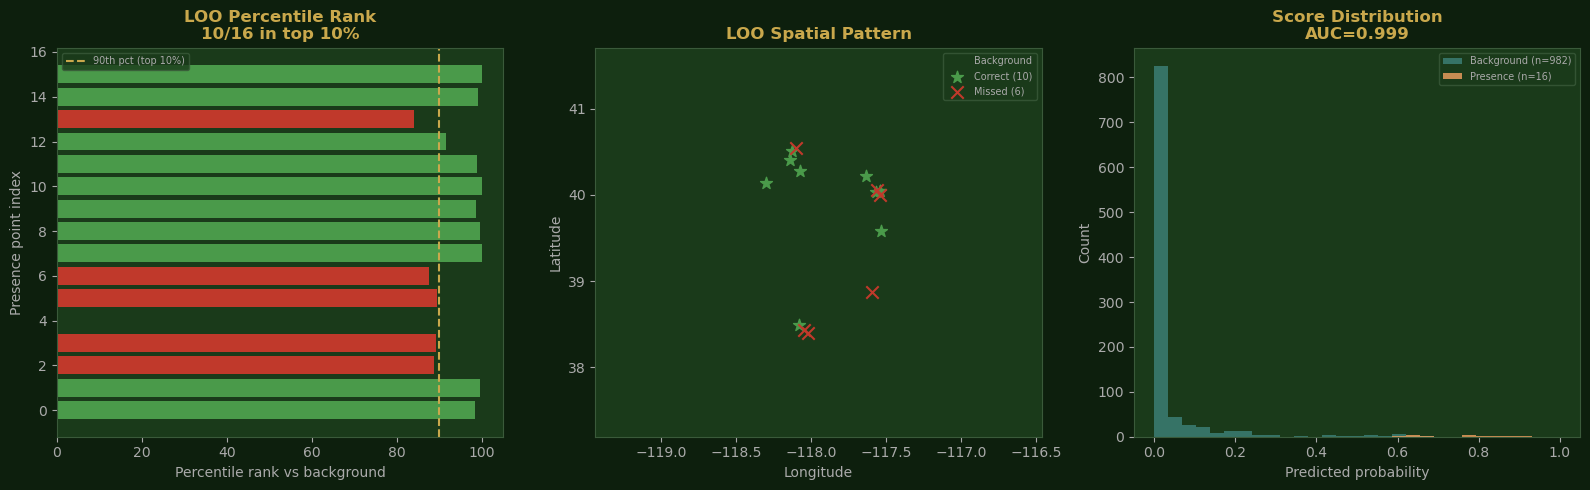

Saved: outputs/loo_validation_paleowave.png


In [7]:
# ── Cell 7: LOO plots ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0d1f0d')

# Panel 1 — percentile rank distribution
ax = axes[0]
colors = ['#4a9a4a' if c else '#c0392b' for c in df_loo['correct']]
ax.barh(range(n_pres), df_loo['pct_rank'], color=colors)
ax.axvline(90, color='#c9a84c', lw=1.5, ls='--', label='90th pct (top 10%)')
ax.set_xlabel('Percentile rank vs background', color='#aaaaaa')
ax.set_ylabel('Presence point index', color='#aaaaaa')
ax.set_title(f'LOO Percentile Rank\n{n_correct}/{n_pres} in top 10%',
             color='#c9a84c', fontweight='bold')
ax.legend(fontsize=7, facecolor='#1a3a1a', labelcolor='#aaaaaa', edgecolor='#3a5a3a')
ax.set_facecolor('#1a3a1a'); ax.tick_params(colors='#aaaaaa')
for sp in ax.spines.values(): sp.set_edgecolor('#3a5a3a')

# Panel 2 — spatial map of correct/incorrect
ax2 = axes[1]
ax2.scatter(df_bg['longitude'], df_bg['latitude'],
            c='#1a3a1a', s=5, alpha=0.4, label='Background')
correct_mask = df_loo['correct']
ax2.scatter(df_loo[correct_mask]['longitude'], df_loo[correct_mask]['latitude'],
            c='#4a9a4a', s=80, marker='*', zorder=5, label=f'Correct ({n_correct})')
ax2.scatter(df_loo[~correct_mask]['longitude'], df_loo[~correct_mask]['latitude'],
            c='#c0392b', s=80, marker='x', zorder=5,
            label=f'Missed ({n_pres - n_correct})')
ax2.set_xlabel('Longitude', color='#aaaaaa')
ax2.set_ylabel('Latitude', color='#aaaaaa')
ax2.set_title('LOO Spatial Pattern', color='#c9a84c', fontweight='bold')
ax2.legend(fontsize=7, facecolor='#1a3a1a', labelcolor='#aaaaaa', edgecolor='#3a5a3a')
ax2.set_facecolor('#1a3a1a'); ax2.tick_params(colors='#aaaaaa')
for sp in ax2.spines.values(): sp.set_edgecolor('#3a5a3a')

# Panel 3 — predicted probability distribution
ax3 = axes[2]
bins = np.linspace(0, 1, 30)
ax3.hist(prob_all[y_all==0], bins=bins, alpha=0.6, color='#4a9a9a',
         label=f'Background (n={int((y_all==0).sum())})')
ax3.hist(prob_all[y_all==1], bins=bins, alpha=0.8, color='#f4a261',
         label=f'Presence (n={int((y_all==1).sum())})')
ax3.set_xlabel('Predicted probability', color='#aaaaaa')
ax3.set_ylabel('Count', color='#aaaaaa')
ax3.set_title(f'Score Distribution\nAUC={auc_proper:.3f}',
              color='#c9a84c', fontweight='bold')
ax3.legend(fontsize=7, facecolor='#1a3a1a', labelcolor='#aaaaaa', edgecolor='#3a5a3a')
ax3.set_facecolor('#1a3a1a'); ax3.tick_params(colors='#aaaaaa')
for sp in ax3.spines.values(): sp.set_edgecolor('#3a5a3a')

fig.patch.set_facecolor('#0d1f0d')
plt.tight_layout()
plt.savefig(OUT_DIR / 'loo_validation_paleowave.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1f0d')
plt.show()
print('Saved: outputs/loo_validation_paleowave.png')

In [8]:
# ── Cell 8: Missed sites analysis ─────────────────────────────────────────
# What do the missed sites have in common?

missed = df_loo[~df_loo['correct']].copy()
hit    = df_loo[df_loo['correct']].copy()

if len(missed) > 0:
    print(f'Missed sites ({len(missed)}):')
    for _, row in missed.iterrows():
        pres_row = df_pres.iloc[int(row['idx'])]
        print(f'  {row["latitude"]:.4f}N {abs(row["longitude"]):.4f}W  '
              f'prob={row["prob"]:.3f}  pct={row["pct_rank"]:.1f}%  '
              f'elev={pres_row["elevation_m"]:.0f}m  '
              f'slope={pres_row["slope_deg"]:.1f}°  '
              f'formation={pres_row.get("formation","?")}' )
else:
    print('No missed sites — perfect recall!')

print(f'\nMean prob — hits:   {hit["prob"].mean():.3f}')
print(f'Mean prob — misses: {missed["prob"].mean():.3f}' if len(missed) else '')

Missed sites (6):
  38.4319N 118.0458W  prob=0.028  pct=88.8%  elev=1573m  slope=3.4°  formation=Luning
  38.4020N 118.0170W  prob=0.085  pct=89.1%  elev=1783m  slope=34.2°  formation=Luning
  40.5481N 118.1000W  prob=0.000  pct=0.0%  elev=1565m  slope=2.9°  formation=nan
  38.8767N 117.5914W  prob=0.072  pct=89.5%  elev=2138m  slope=9.7°  formation=Luning
  40.0592N 117.5589W  prob=0.052  pct=87.6%  elev=1386m  slope=8.0°  formation=Favret
  40.0014N 117.5394W  prob=0.019  pct=84.0%  elev=2355m  slope=13.0°  formation=Favret

Mean prob — hits:   0.543
Mean prob — misses: 0.043


In [9]:
# ── Cell 9: Save LOO results and summary ───────────────────────────────────

df_loo.to_csv(MODEL_DIR / 'paleowave_loo_results.csv', index=False)

print(f"""
{'='*60}
  PaleoWave LOO Validation
{'='*60}
  Background: {len(df_bg)} points
    Grid:     {GRID_DEG}° regular
    Buffer:   {EXCL_KM}km exclusion around presence

  Presence:   {n_pres} unique locations
  Features:   {FEATURE_COLS}

  AUC (proper background): {auc_proper:.3f}
  LOO recall @ top 10%:    {n_correct}/{n_pres} ({recall:.1%})

  Missed sites: {n_pres - n_correct}

  Feature importances:
{''.join(f'    {f:15s}: {i:.3f}{chr(10)}'
         for f, i in sorted(zip(FEATURE_COLS, rf_final.feature_importances_),
                             key=lambda x: -x[1]))}
  Saved:
  data/model/paleowave_rf_v2_final.joblib
  data/model/paleowave_loo_results.csv
  data/pbdb/paleowave_background_proper.csv
  outputs/loo_validation_paleowave.png
{'='*60}""")


  PaleoWave LOO Validation
  Background: 982 points
    Grid:     0.1° regular
    Buffer:   25.0km exclusion around presence

  Presence:   16 unique locations
  Features:   ['elevation_m', 'slope_deg', 'aspect_deg', 'tri']

  AUC (proper background): 0.999
  LOO recall @ top 10%:    10/16 (62.5%)

  Missed sites: 6

  Feature importances:
    tri            : 0.569
    slope_deg      : 0.225
    elevation_m    : 0.132
    aspect_deg     : 0.073

  Saved:
  data/model/paleowave_rf_v2_final.joblib
  data/model/paleowave_loo_results.csv
  data/pbdb/paleowave_background_proper.csv
  outputs/loo_validation_paleowave.png
